In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pprint
import os
import glob

In [96]:


# Set the parent directory path
parent_directory = "C:/Users/lqc/QM_5-28-24" #"path/to/parent/directory"
qubit = 3
target_string = 'ramseycorrelation'

# Use glob to recursively search for files containing the target string
files = glob.glob(f"{parent_directory}/2025-02-1[78]/*{target_string}*", recursive=True)  #[1-2][90]
files = sorted(files, key=os.path.getmtime)  # Time order

file_names = []
for i, file in enumerate(files):
    print(i, file)
    file_names.append(file)

0 C:/Users/lqc/QM_5-28-24\2025-02-17\#65418_e_f_ramseycorrelation_000818
1 C:/Users/lqc/QM_5-28-24\2025-02-17\#65443_e_f_ramseycorrelation_011447
2 C:/Users/lqc/QM_5-28-24\2025-02-17\#65468_e_f_ramseycorrelation_022120
3 C:/Users/lqc/QM_5-28-24\2025-02-17\#65481_e_f_ramseycorrelation_025510
4 C:/Users/lqc/QM_5-28-24\2025-02-17\#65564_e_f_ramseycorrelation_063751
5 C:/Users/lqc/QM_5-28-24\2025-02-17\#65613_e_f_ramseycorrelation_084951
6 C:/Users/lqc/QM_5-28-24\2025-02-17\#65626_e_f_ramseycorrelation_092316
7 C:/Users/lqc/QM_5-28-24\2025-02-17\#65758_e_f_ramseycorrelation_155505
8 C:/Users/lqc/QM_5-28-24\2025-02-17\#65784_e_f_ramseycorrelation_164835
9 C:/Users/lqc/QM_5-28-24\2025-02-17\#65855_e_f_ramseycorrelation_200519
10 C:/Users/lqc/QM_5-28-24\2025-02-18\#65950_e_f_ramseycorrelation_002234
11 C:/Users/lqc/QM_5-28-24\2025-02-18\#65987_e_f_ramseycorrelation_020136
12 C:/Users/lqc/QM_5-28-24\2025-02-18\#66000_e_f_ramseycorrelation_023448
13 C:/Users/lqc/QM_5-28-24\2025-02-18\#66025_e_f

Monte Carlo Correlation

In [97]:
lags = np.concatenate((np.arange(1,40,1),np.arange(50,151,10)))
n_samples = 5_000
n_bootstrap = 10

t_diffs_dict = {}
i_diffs_dict = {}
for iif in range(7,16):
    all_I_bootstraps = np.zeros((n_bootstrap,n_samples*len(lags)))
    all_t_bootstraps = np.zeros((n_bootstrap,n_samples*len(lags)))
    for i_bs in range(n_bootstrap):

        # fn = 'C:/Users/lqc/QM_5-28-24/2025-02-12/#63375_e_f_ramseycorrelation_103932'
        fn = file_names[iif]
        file_contents = np.load(fn+'/arrays.npz')
        # Open the file and load the data
        with open(fn+'/data.json', 'r') as file:
            data_dict = json.load(file)

        ef_threshold = data_dict['RR_CONSTANTS']['q3_re']['ge_threshold']
        ge_threshold = data_dict['RR_CONSTANTS']['q3_rr']['ge_threshold']
        I2 = file_contents['measurement_data.q3_re.I']
        Ige = file_contents['measurement_data.q3_re.Ige']
        # print(len(I2))
        ts = file_contents['measurement_data.q3_re.timestamps']
        Ithresholded = np.array([1 if ii[0] > ef_threshold else 0 for ii in I2])
        Igethresholded = np.array([1 if ii[0] > ge_threshold else 0 for ii in Ige])
        ts = np.array([tt[0]*4 for tt in ts])
        # Remove all data points where we measured g
        ts = ts[Igethresholded==1]
        Ithresholded = Ithresholded[Igethresholded==1]
        I2post = I2[Igethresholded==1]

        all_I_diffs = np.zeros(n_samples*len(lags))
        all_t_diffs = np.zeros(n_samples*len(lags))
        for i_l, lag in enumerate(lags):
            # -lag -1 to avoid indices out of bounds
            indices = np.random.choice(len(Ithresholded)-lag-1,n_samples,replace=False)
            lagged_indices = indices + lag

            I_base_values = Ithresholded[indices]
            I_lag_values = Ithresholded[lagged_indices]
            t_base_values = ts[indices]
            t_lag_values = ts[lagged_indices]

            I_diff = np.abs(I_lag_values - I_base_values)
            t_diff = t_lag_values - t_base_values

            all_I_diffs[i_l*n_samples:(i_l + 1)*n_samples] = I_diff
            all_t_diffs[i_l*n_samples:(i_l + 1)*n_samples] = t_diff

        # Sort the list by shorted to longest time interval
        all_I_diffs = [x for _, x in sorted(zip(all_t_diffs, all_I_diffs))]
        # sort and convert to ms
        all_t_diffs.sort()
        all_t_diffs = all_t_diffs*1e-6
        all_I_bootstraps[i_bs] = all_I_diffs
        all_t_bootstraps[i_bs] = all_t_diffs
    t_diffs_dict[fn]=all_t_bootstraps
    i_diffs_dict[fn]=all_I_bootstraps

(0.2, 0.55)

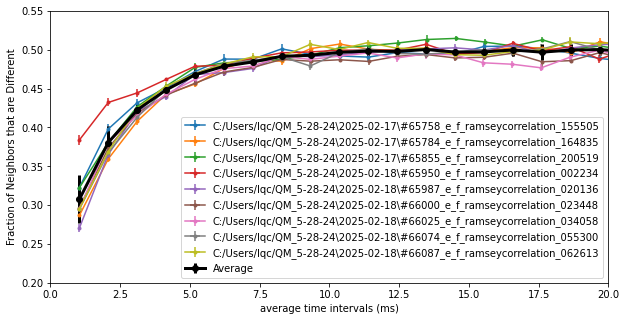

In [98]:
t_bin_width = 1 # width of histogram bins in ms

fig = plt.figure(figsize = (10,5))
i_plot = 0
i_plot_neglect = -30 # crop the plot data at this index
# Loop over each file's sorted results

for i_file, key in enumerate(t_diffs_dict.keys()):
    all_t_diffs = t_diffs_dict[key]
    all_I_diffs = i_diffs_dict[key]
    
    #estimate the number of bins (we won't use them all)   
    nbinest = round(all_t_diffs[0][-1]/t_bin_width)
    ts_binned = np.zeros((n_bootstrap, nbinest))
    tstd_binned = np.zeros((n_bootstrap, nbinest))
    Is_binned = np.zeros((n_bootstrap, nbinest))
    if i_file == 0:
        depth_all_files = nbinest
        all_files_i = np.zeros((len(t_diffs_dict.keys()), nbinest))
        all_files_t = np.zeros((len(t_diffs_dict.keys()), nbinest))


    for i_bs in range(n_bootstrap):
        # Bin the data
        t0=np.min(np.min(all_t_diffs))*0.9  # initialize time interval lower bound
        i_old = 0  # initialize index lower bound
        i_bin = 0  # initialize bin index

        for i_t , t in enumerate(all_t_diffs[i_bs]):
            if i_bin == nbinest:
                continue
            if t-t0 > t_bin_width:
                # entering a new bin
                t_bin = all_t_diffs[i_bs][i_old:i_t]
                is_bin = all_I_diffs[i_bs][i_old:i_t]

                ts_binned[i_bs][i_bin] = np.mean(t_bin)
                tstd_binned[i_bs][i_bin] = np.std(t_bin)
                Is_binned[i_bs][i_bin] = np.mean(is_bin)

                t0 += t_bin_width
                i_old = i_t
                i_bin += 1
    # After generating all bootstrapped data points, we can take final avg and std
    Is_binned_final = np.mean(Is_binned, axis=0)
    Istd_binned_final = np.std(Is_binned, axis=0)
    ts_binned_final = np.mean(ts_binned, axis=0)
    tstd_binned_final = np.mean(tstd_binned, axis=0)

    # Note: std of I doesn't make sense since the individual values are either 0 or 1.
    # We need to perform bootstrapping to get the errorbars on I values
    plt.errorbar(ts_binned_final[:i_plot_neglect], Is_binned_final[:i_plot_neglect], 
                 yerr=Istd_binned_final[:i_plot_neglect], xerr=tstd_binned_final[:i_plot_neglect],
                   label = key, linestyle='-', fmt='.')
    last_ind = np.min([depth_all_files, nbinest])
    all_files_i[i_file][:last_ind] = Is_binned_final[:last_ind]
    all_files_t[i_file][:last_ind] = ts_binned_final[:last_ind]

plt.xlabel('average time intervals (ms)')
plt.ylabel('Fraction of Neighbors that are Different')
avg_i = np.mean(all_files_i, axis=0)
avg_t = np.mean(all_files_t, axis=0)
std_i = np.std(all_files_i, axis=0)
std_t = np.std(all_files_t, axis=0)
plt.errorbar(avg_t[:i_plot_neglect], avg_i[:i_plot_neglect], 
                 yerr=std_i[:i_plot_neglect], xerr=std_t[:i_plot_neglect],
                   label = 'Average', linestyle='-', fmt='o', linewidth=3, color = (0,0,0))
plt.legend()
plt.xlim(0,20)
plt.ylim(0.20,0.55)



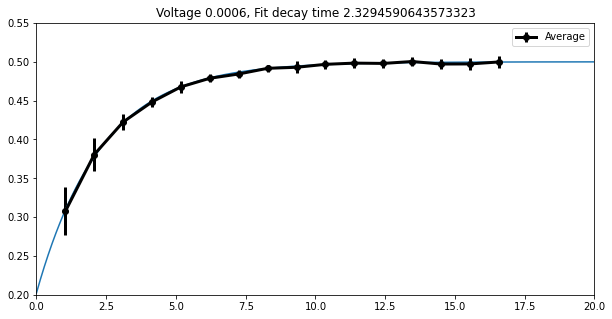

[2.32945906 0.20232503]


In [99]:
from scipy import optimize
fig = plt.figure(figsize = (10,5))
i_plot_neglect = 16
plt.errorbar(avg_t[:i_plot_neglect], avg_i[:i_plot_neglect], 
                 yerr=std_i[:i_plot_neglect], xerr=std_t[:i_plot_neglect],
                   label = 'Average', linestyle='-', fmt='o', linewidth=3, color = (0,0,0))
plt.legend()
plt.xlim(0,20)
plt.ylim(0.20,0.55)

ffunc = lambda x, *p: (0.5 - p[1])*(1- np.exp(-x/p[0])) + p[1]
p0 = [3,0.32]
bounds = (
    [0.1, 0],
    [50, 0.5]
)
fit_params1, covar, infodict, mesg, ier = optimize.curve_fit(ffunc, avg_t[:i_plot_neglect],avg_i[:i_plot_neglect], p0=p0, full_output= True,
                bounds=bounds) #, sigma=std_i[:i_plot_neglect])

x = np.linspace(0,20, 1000)
fy = ffunc(x,*fit_params1)
plt.plot(x, fy)
plt.title(f'Voltage 0.0006, Fit decay time {fit_params1[0]}')
plt.show()

print(fit_params1)
        

In [6]:
import json
# collect everything into a dictionary to save
save_t_diff = {key: list(value) for key, value in t_diffs_dict.items()}
save_i_diff = {key: list(value) for key, value in i_diffs_dict.items()}
json_dict = {
    'file_names': list(file_names),
    'Time_intervals_dict': save_t_diff,
    'Neighbor_difference_dict': save_i_diff,
}
formatted_dict = json.dumps(json_dict)
with open('montecarlocorrelation_02172025.json', 'w') as json_file:
    json.dump(formatted_dict, fp=json_file)

In [4]:
def rolling_correlation(Ithresholded, timestamps, n_max, n_step=1, n_sample=20):
    lnr = len(range(1,n_max,n_step))
    avg_delta_ts = np.zeros(lnr)    
    std_delta_ts = np.zeros(lnr)
    fractions = np.zeros(lnr)
    for i_n, n in enumerate(range(1,n_max, n_step)):
        rolling_sum = 0
        rolling_length = 0
        for i in range(0,n,int(np.floor(n/n_sample+1))):
            rolling_list = Ithresholded[i::n]
            diffs = np.abs(np.diff(rolling_list))
            rolling_sum += np.sum(diffs)
            rolling_length += len(diffs)

            rolling_times = timestamps[i::n]
            if i ==0:
                tdiffs = np.diff(rolling_times)
            else:
                tdiffs = np.concatenate((tdiffs, np.diff(rolling_times)))
        fractions[i_n] = rolling_sum/rolling_length
        avg_delta_ts[i_n] = np.mean(tdiffs)
        std_delta_ts[i_n] = np.std(tdiffs)
    return fractions, avg_delta_ts, std_delta_ts


def time_interval_analysis(Ithresholded, timestamps):
    tss=timestamps[Ithresholded==1]
    tsdiff = np.diff(tss)
    plt.hist(tsdiff, bins=20)
    plt.show()

fig = plt.figure(figsize=(10,5))
for i_file in range(56,57): #
    file_contents = np.load(file_names[i_file]+'/arrays.npz')
    # Open the file and load the data
    with open(file_names[i_file]+'/data.json', 'r') as file:
        data_dict = json.load(file)

    i_threshold = data_dict['RR_CONSTANTS']['q3_re']['ge_threshold']
    I2 = file_contents['measurement_data.q3_re.I']
    ts = file_contents['measurement_data.q3_re.timestamps']
    Ithresholded = np.array([1 if ii[0] > i_threshold else 0 for ii in I2])
    ts = np.array([tt[0]*4 for tt in ts])

    #nth nearest neighbor
    fractions, deltats, stdts = rolling_correlation(Ithresholded, ts, 22,1)
    plt.errorbar(deltats*1e-6, fractions, xerr=stdts*1e-6, label = file_names[i_file])

plt.xlabel('average time intervals (ms)')
plt.ylabel('Fraction of Neighbors that are Different')
plt.legend()
plt.show()

time_interval_analysis(Ithresholded, ts*1e-6)

IndexError: list index out of range

<Figure size 720x360 with 0 Axes>

2 Step Readout Post selection

1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000
1500000


KeyboardInterrupt: 

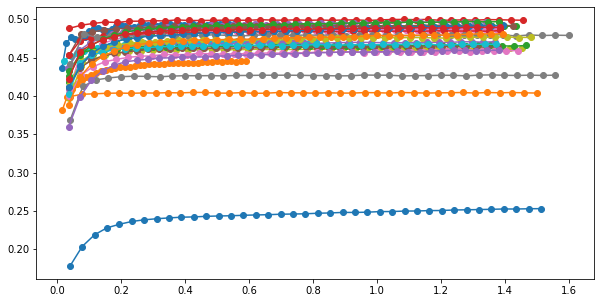

In [339]:
fig = plt.figure(figsize=(10,5))
for iif in range(len(file_names)): #

    # fn = 'C:/Users/lqc/QM_5-28-24/2025-02-12/#63375_e_f_ramseycorrelation_103932'
    fn = file_names[iif]
    file_contents = np.load(fn+'/arrays.npz')
    # Open the file and load the data
    with open(fn+'/data.json', 'r') as file:
        data_dict = json.load(file)

    ef_threshold = data_dict['RR_CONSTANTS']['q3_re']['ge_threshold']
    ge_threshold = data_dict['RR_CONSTANTS']['q3_rr']['ge_threshold']
    I2 = file_contents['measurement_data.q3_re.I']
    Ige = file_contents['measurement_data.q3_re.Ige']
    # print(len(I2))
    ts = file_contents['measurement_data.q3_re.timestamps']
    Ithresholded = np.array([1 if ii[0] > ef_threshold else 0 for ii in I2])
    Igethresholded = np.array([1 if ii[0] > ge_threshold else 0 for ii in Ige])
    ts = np.array([tt[0]*4 for tt in ts])
    # Remove all data points where we measured g
    ts = ts[Igethresholded==1]
    Ithresholded = Ithresholded[Igethresholded==1]
    I2post = I2[Igethresholded==1]


    #nth nearest neighbor
    fractions, deltats, stdts = rolling_correlation(Ithresholded, ts,40,1,40)
    plt.errorbar(deltats*1e-6, fractions, xerr=stdts*1e-6, label = file_names[iif], linestyle='-', fmt='o')
plt.xlabel('average time intervals (ms)')
plt.ylabel('Fraction of Neighbors that are Different')
plt.legend()
plt.show()

    # time_interval_analysis(Ithresholded, ts*1e-6)
# print(deltats)

1500000


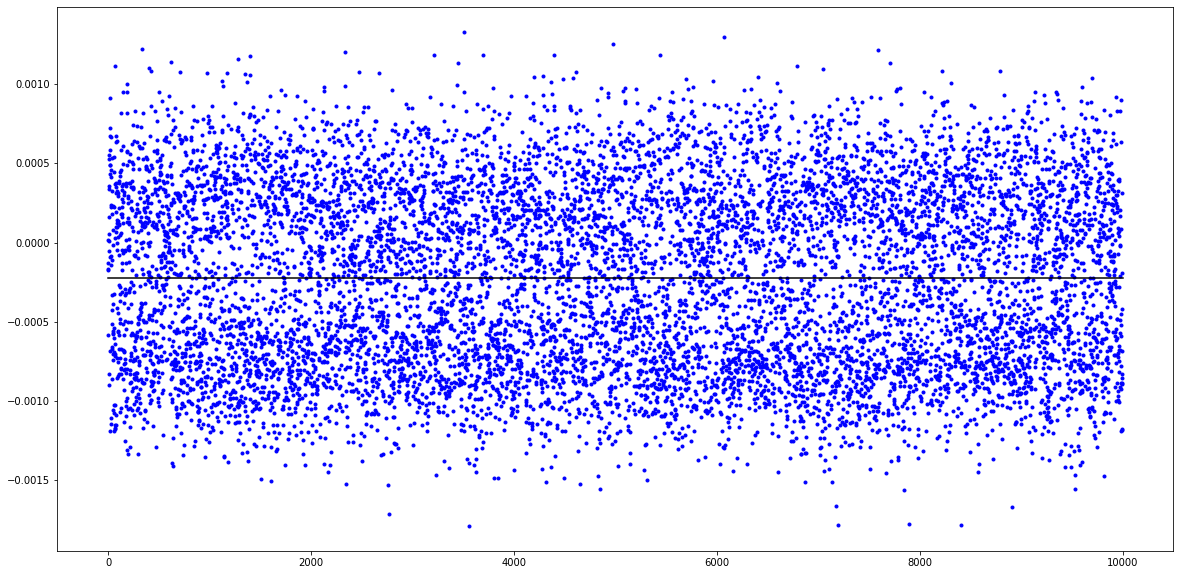

In [333]:
i_slice = 10_000

fn = file_names[0]
file_contents = np.load(fn+'/arrays.npz')
# Open the file and load the data
with open(fn+'/data.json', 'r') as file:
    data_dict = json.load(file)

ef_threshold = data_dict['RR_CONSTANTS']['q3_re']['ge_threshold']
ge_threshold = data_dict['RR_CONSTANTS']['q3_rr']['ge_threshold']
I2 = file_contents['measurement_data.q3_re.I']
Ige = file_contents['measurement_data.q3_re.Ige']
print(len(I2))
ts = file_contents['measurement_data.q3_re.timestamps']
Ithresholded = np.array([1 if ii[0] > ef_threshold else 0 for ii in I2])
Igethresholded = np.array([1 if ii[0] > ge_threshold else 0 for ii in Ige])
ts = np.array([tt[0]*4 for tt in ts])
# post-select
ts = ts[Igethresholded==1]
Ithresholded = Ithresholded[Igethresholded==1]
I2post = I2[Igethresholded==1]
fig = plt.figure(figsize=(20,10))
dat=I2post[:i_slice]
plt.plot(dat, 'b.')
plt.plot([0,len(dat)],[ef_threshold,ef_threshold],'k-')
# plt.plot(Ige[:i_slice], 'r.')
# plt.plot([0,len(dat)],[ge_threshold,ge_threshold],'k--')

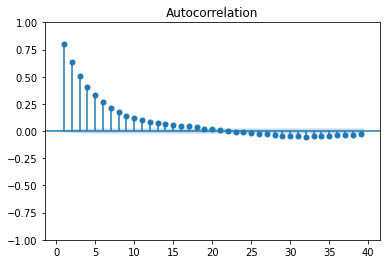

In [283]:
# pip install statsmodels
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Sample data
data = binary_state

# Plot autocorrelation
plot_acf(data, lags=np.arange(1,40,1))
plt.show()


Model Random Coin Flips

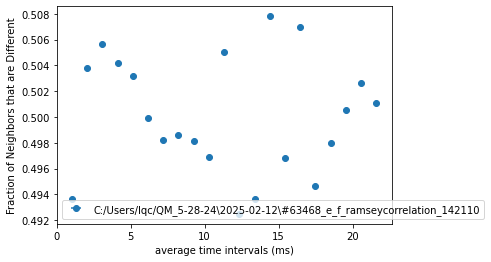

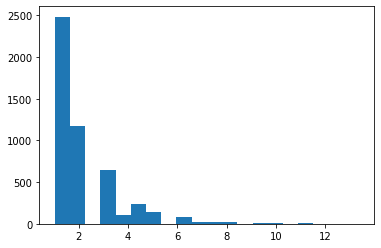

In [121]:
flips = np.random.choice([0,1],10_000)
fractions, deltats, stdts = rolling_correlation(flips, ts, 22,1)
plt.errorbar(deltats*1e-6, fractions, xerr=stdts*1e-6, label = file_names[iif], linestyle='none', fmt='o')
plt.xlabel('average time intervals (ms)')
plt.ylabel('Fraction of Neighbors that are Different')
plt.legend()
plt.show()

time_interval_analysis(flips, ts*1e-6)


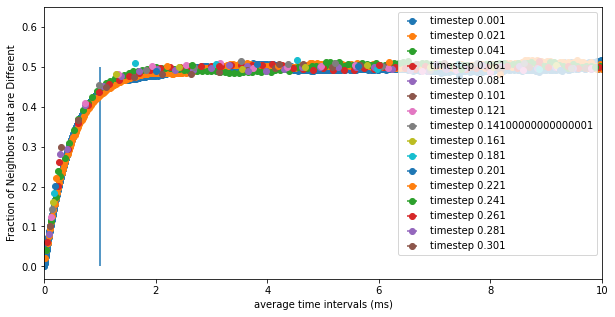

In [51]:
# sample_timestep = 0.001 # ms
f = plt.figure(figsize=(10,5))
for sample_timestep in np.arange( 0.001, 0.302, 0.02):
    sample_duration = 3000 # ms
    flip_rate = 1 # kHz

    num_samples = int(round(sample_duration/sample_timestep))
    simulated_timestamps = np.arange(0,sample_duration, sample_timestep)

    binary_state = np.zeros(num_samples)

    rand_at_timestep = np.random.random(num_samples)

    convert_to_flip_event = lambda x: 1 if x<(sample_timestep*flip_rate) else 0

    flip_events = list(map(convert_to_flip_event, rand_at_timestep))

    flip_indices = [i for i, e in enumerate(flip_events) if e == 1]

    ind = 0
    flip_exponent = 0
    for i_f in range(len(flip_indices)-1):
        binary_state[flip_indices[i_f]:flip_indices[i_f+1]] += (-1)**flip_exponent + binary_state[flip_indices[i_f]-1]
        flip_exponent += 1


    fractions, deltats, stdts = rolling_correlation(binary_state, simulated_timestamps, int(np.ceil(200/sample_timestep)),int(np.ceil(40*sample_timestep)))
    plt.errorbar(deltats, fractions, xerr=stdts, label = f'timestep {sample_timestep}', linestyle='none', fmt='o')
plt.xlabel('average time intervals (ms)')
plt.ylabel('Fraction of Neighbors that are Different')
plt.xlim(0,10)
plt.legend()
plt.vlines([1], 0, 0.5)
plt.show()

# time_interval_analysis(binary_state, simulated_timestamps)

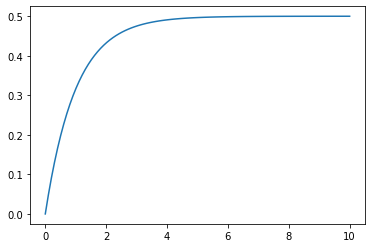

In [77]:
ffunc = lambda x, *p: 0.5*(1- np.exp(-x/p[0]))

x = np.linspace(0,10, 100)
fy = ffunc(x,[1])
plt.plot(x, fy)
plt.show()